# Solar System planets image classification
### Inteligencia Artirficial para los Sistemas de Control Autónomos
### Máster de Ciencia y Tecnología desde el Espacio


## Objectives

- Introduce some basic Machine Learning concepts.
- Work with a basic Machine Learning workflow.
- Illustrate an application of classical Machine Learning to image classification.
- Understand the importance of hyperparameter settings.

## Introduction

In this assignment we will implement a Computer Vision application of Machine Learning. We will train a classifier able to identify a planet of the Solar System given a picture of it. The main goal of this assignment is to implement a basic Machine Learning workflow and practice some tasks needed in any Machine Learning project, such as model training, model evaluation or hyperparameter optimization.

Remember that the workflow usually implemented in ML projects is as follows.

1. Data adquisition
2. Exploratory analysis
3. Data preprocessing
4. Model training
5. Model validation

This assignment uses a dataset created by Emirhan Bulut.

## Libraries import

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

## Load dataset

Given that the dataset is a collection of images, first we need to download them in order to build our feature matrix. To that end we use a nice feature of notebooks that allows to execute a system command. You do not need to know how the following command works, all you need is to know that it is going to download a zip file from Internet containing the images.

You can execute any shell command in Jupyter using "!", as the following line that downloads the dataset from a web server:

In [3]:
!wget https://github.com/emirhanai/Planets-and-Moons-Dataset-AI-in-Space/raw/main/Planets_Moons_Data.zip

--2026-03-29 15:19:46--  https://github.com/emirhanai/Planets-and-Moons-Dataset-AI-in-Space/raw/main/Planets_Moons_Data.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/emirhanai/Planets-and-Moons-Dataset-AI-in-Space/main/Planets_Moons_Data.zip [following]
--2026-03-29 15:19:47--  https://raw.githubusercontent.com/emirhanai/Planets-and-Moons-Dataset-AI-in-Space/main/Planets_Moons_Data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21015623 (20M) [application/zip]
Saving to: ‘Planets_Moons_Data.zip’

Planets_Moons_Data. 100%[===================>]  20.04M  --.-KB/s    in 0.1s    

2026-03-

In [4]:
!unzip Planets_Moons_Data.zip

Archive:  Planets_Moons_Data.zip
   creating: Planets and Moons/
   creating: Planets and Moons/Earth/
  inflating: Planets and Moons/Earth/Earth (1).jpg  
  inflating: Planets and Moons/Earth/Earth (10).jpg  
  inflating: Planets and Moons/Earth/Earth (100).jpg  
  inflating: Planets and Moons/Earth/Earth (101).jpg  
  inflating: Planets and Moons/Earth/Earth (102).jpg  
  inflating: Planets and Moons/Earth/Earth (103).jpg  
  inflating: Planets and Moons/Earth/Earth (104).jpg  
  inflating: Planets and Moons/Earth/Earth (105).jpg  
  inflating: Planets and Moons/Earth/Earth (106).jpg  
  inflating: Planets and Moons/Earth/Earth (107).jpg  
  inflating: Planets and Moons/Earth/Earth (108).jpg  
  inflating: Planets and Moons/Earth/Earth (109).jpg  
  inflating: Planets and Moons/Earth/Earth (11).jpg  
  inflating: Planets and Moons/Earth/Earth (110).jpg  
  inflating: Planets and Moons/Earth/Earth (111).jpg  
  inflating: Planets and Moons/Earth/Earth (112).jpg  
  inflating: Planets 

Let's checkout if the dataset has been correctly downloaded.

In [5]:
!ls -l

total 20532
drwxr-xr-x 13 root root     4096 May  8  2022 'Planets and Moons'
-rw-r--r--  1 root root 21015623 Mar 29 15:19  Planets_Moons_Data.zip
drwxr-xr-x  1 root root     4096 Mar 23 13:29  sample_data


It would be better to visualize one of the images.

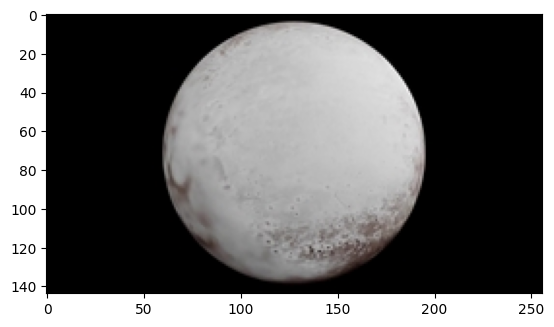

In [6]:
import os
import pandas as pd
import time
from tqdm.notebook import tqdm
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

from PIL import ImageOps

DATAPATH = "Planets and Moons"

img = Image.open(os.path.join(DATAPATH, "Pluto/Pluto (100).jpg"))
img.load()
plt.imshow(img)

In [7]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

We can transform the image to a plain numpy array simply as.

In [8]:
np.asarray(img, dtype="uint8").shape

(144, 256, 3)

## Build the dataset

Given the collection of images, we need to extract the features to build the dataset. That is done in the following code, that you do not need to understand.

In [9]:
DATAPATH = "Planets and Moons"


columnNames = list()
columnNames.append('label')
size = 28 * 28 * 3

for i in range(size):
    pixel = str(i)
    columnNames.append('pixel' + pixel)

# Create a Pandas dataframe for storing data
df = pd.DataFrame(columns = columnNames)

for dirs in tqdm(os.listdir(DATAPATH)):
    print("Iterating: " + dirs + " folder")

    for file in tqdm(os.listdir(os.path.join(DATAPATH, dirs))):
        #print("Doing " + file)
        img = Image.open(os.path.join(DATAPATH, dirs, file))
        img.load()

        border = (58, 2, 58, 2) # left, top, right, bottom
        img = ImageOps.crop(img, border)
        img = img.resize((28, 28))

        # create a numpy array for image pixels
        imgdata = np.asarray(img, dtype="uint8")
        #print(imgdata.shape)
        imgdata = imgdata.reshape(1, -1)
        row = pd.DataFrame(imgdata)
        row.columns = columnNames[1:] # First entry is 'label', avoid it
        row['label'] = dirs

        df = pd.concat([df, row])

  0%|          | 0/11 [00:00<?, ?it/s]

Iterating: Moon folder


  0%|          | 0/148 [00:00<?, ?it/s]

Iterating: Earth folder


  0%|          | 0/149 [00:00<?, ?it/s]

...

  0%|          | 0/149 [00:00<?, ?it/s]

Iterating: MakeMake folder


  0%|          | 0/149 [00:00<?, ?it/s]

Iterating: Mercury folder


  0%|          | 0/149 [00:00<?, ?it/s]

The variable df contains a dataframe with the images in a Machine Learning friendly format. The process of building the dataset may be time-consuming in case of large amount of data. For this reason it is quite common to store it in disk.

In [10]:
df.to_csv("planets.csv", index=False)

This file has been created in the virtual machine, so you do not have direct access to it, but you can still download it with the following code.

In [11]:
from IPython.display import FileLink

display(FileLink("planets.csv"))

/content/planets.csv

## Exploratory analysis

As usual, we try to identify NaN and null values, number of instances, attributes and classes, outlayers, correlations and in general any information about our data that helps us to better understand it and hence train better models. You may be interested (and you certainly should be) in taking a look at the images, download them [from this link](https://github.com/dfbarrero/dataCourse/raw/master/assignments/planets/Planets_Moons_Data.zip).

**EDA**

Visualización de los datos sin procesar

In [12]:

display(df)
df.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Mercury,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Mercury,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Mercury,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Mercury,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Moon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Número de instancias y atributos (filas y columnas)

In [13]:
df.shape #Tiene 1638 filas y 2353 columnas

(1638, 2353)

Identificación de las variables

In [14]:
df.columns #Muestra las etiquetas de las columnas

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel2342', 'pixel2343', 'pixel2344', 'pixel2345', 'pixel2346',
       'pixel2347', 'pixel2348', 'pixel2349', 'pixel2350', 'pixel2351'],
      dtype='object', length=2353)

In [15]:
df.dtypes #tipo de dato de cada columna

,0
label,object
pixel0,object
pixel1,object
pixel2,object
pixel3,object
...,...
pixel2347,object
pixel2348,object
pixel2349,object
pixel2350,object


Verificar si hay duplicados y NaN

In [16]:
#Descubrir si hay NaN
dfcleanNaN=df.dropna()
print(f"Filas totales:{len(df)}")#Filas totales tiene el data frame original
print(f"Filas sin Nan:{len(dfcleanNaN.dropna())}")#Filas quedan después de eliminar las que tienen NaN
print(f"Filas con Nan:{len(df)-len(dfcleanNaN.dropna())}")
#Descubrir si hay duplicados
dfcleanDUP=df.drop_duplicates()
print(f"Filas sin duplicados:{len(dfcleanDUP.drop_duplicates())}")
print(f"Filas con duplicados:{len(df)-len(dfcleanDUP.drop_duplicates())}")

Filas totales:1638
Filas sin Nan:1638
Filas con Nan:0
Filas sin duplicados:1634
Filas con duplicados:4


Tratamiento de los datos

In [17]:
#Viendo que hay duplicados y que no hay NaN, vamos a procesar df
df.drop_duplicates(inplace=True)#Eliminamos las filas duplicadas
df.shape #Para comprobar que se han borrado bien las cuatro filas duplicadas

(1634, 2353)

In [18]:
for (name, group) in df.groupby('label'):
    print("-----> " + name + " <-----")
    display(group)
    print("\n")

-----> Earth <-----


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0




-----> Jupiter <-----


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Jupiter,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0




-----> MakeMake <-----


...

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235
0,Saturn,233,233,233,233,233,233,233,233,233,...,233,233,233,233,235,235,235,235,235,235




-----> Uranus <-----


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Uranus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0




-----> Venus <-----


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,Venus,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Distribución de clases

<Axes: xlabel='label'>

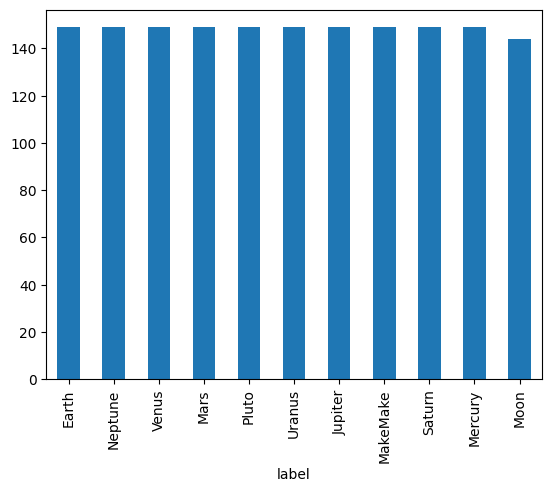

In [19]:
df['label'].value_counts().plot(kind='bar')#Y donde vemos las filas duplicadas que hemos eliminado de la Luna

Estadísticas de resumen (promedio, maximo y mínimo)

In [20]:
df.describe()
#El resultado nos dice que tenemos 11 clases y la clase más común es Tierra (Todos los planetas/lunas tienen 149 imágenes suyas salvo Moon, que tiene 144, porque tenía filas duplicadas)
#En las columnas pixel tenemos dos valores posibles y casi siempre suelen ser fondo (negro=0) (1485 veces)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
count,1634,1634,1634,1634,1634,1634,1634,1634,1634,1634,...,1634,1634,1634,1634,1634,1634,1634,1634,1634,1634
unique,11,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,Earth,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,149,1485,1485,1485,1485,1485,1485,1485,1485,1485,...,1485,1485,1485,1485,1485,1485,1485,1485,1485,1485


Vamos a ver los valores que toman los pixel cuando no es 0

In [21]:

#df.iloc[] hace que nos quedemos con todo el dataframe salvo con la columna label.La función stack convierte al dataframe en una sola columna y unique devuelve los valores que son distintos
valores = df.iloc[:, 1:].stack().unique()
valores = valores[valores != 0] #Nos quedamos con los valores que son distintos de 0
print(valores) #Entonces vemos que tenemos una escala de grises, donde el 0 es el negro y a un número más alto, más blanco es el pixel.

[8 27 46 48 47 40 25 1 59 94 102 101 97 96 91 90 92 87 86 81 80 60 61 21
 69 78 77 65 66 64 68 58 83 82 84 85 89 95 93 70 71 19 49 50 51 54 55 52
 57 42 38 41 39 43 44 53 56 79 105 36 37 35 45 103 34 33 32 62 63 75 20 29
 30 31 67 3 26 28 22 24 23 6 7 18 17 12 13 16 14 15 11 5 10 9 2 4 139 138
 149 147 148 146 140 134 132 133 109 108 131 177 172 170 171 157 155 156
 143 141 142 130 128 129 135 126 124 125 144 136 88 76 181 182 185 186 158
 151 120 118 122 121 137 123 188 187 174 173 127 194 175 165 163 164 161
 160 150 119 145 191 190 159 162 107 176 180 179 152 74 113 117 106 115
 116 114 111 112 110 100 168 99 98 104 153 167 154 169 72 73 189 166 183
 178 192 198 184 202 203 206 193 199 197 200 196 204 205 195 201 207 208
 213 209 211 216 214 215 212 220 219 224 222 210 230 221 218 227 228 226
 217 223 231 232 229 233 234 235 238 225 237 239 236 242 240 241 243]


Histograma de intensidades de los pixel

<Axes: >

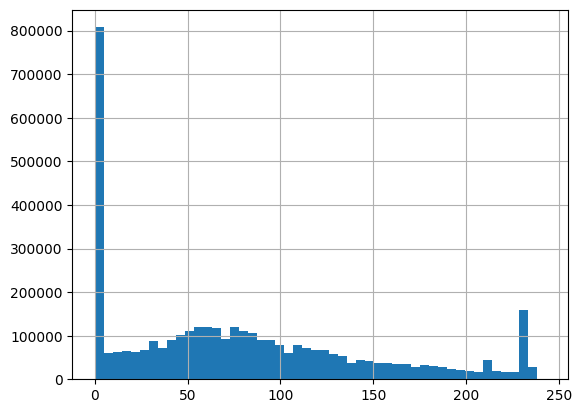

In [22]:
df.iloc[:, 1:].stack().hist(bins=50) #Para comprobar que como se mencionó anteriormente, la mayor parte de los píxeles corresponden al fondo (negro).
#También observamos un pico pequeño a la derecha y que nos dice que también tenemos una gran cantidad de píxeles muy brillantes

Histograma de intensidades por Planeta

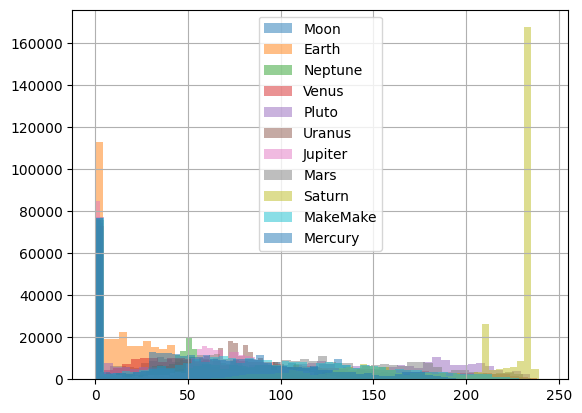

In [23]:
for label in df['label'].unique():
    subset = df[df['label'] == label]
    subset.iloc[:, 1:].stack().hist(bins=50, alpha=0.5, label=label)
plt.legend()
plt.show()
#Así vemos como Saturno tiene una alta concentración de pixeles brillantes, mientras que la Tierra y la Luna, una concentración mucho más baja.

The conclusion should be that the dataset is perfecty balanced with 11 classes, clean, without outlayers and valid for predictive modeling.

## Preprocess data

Our data have values between 0 and 255, which is not optimal for some of the algorithms we will try, so we normalize them. In this case the variance of our attributes is quite similar, if not identical, so normalization will not make a big difference, however, we will do it, but before that we build the feature matrix and target vector as Scikit-Learn requires.

In [24]:
x = df.drop("label", axis=1)
y = df["label"]

display(x.head())
display(y.head())

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel2342,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,label
0,Moon
0,Moon
0,Moon
0,Moon
0,Moon


Now we standarize our data.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(x) #Es un normalizador X=(x-mu)/sigma. Lo que hace es calcular mu y sigma
X = scaler.transform(x) #Calcula la transformación

X[0]#Devuelve la primera fila transformada

array([-0.31675969, -0.31675969, -0.31675969, ..., -0.31675969,
       -0.31675969, -0.31675969])

We split our data into train and test datasets.

In [26]:
from sklearn.model_selection import train_test_split #Divide los datos en un 70% para entrenar el modelo y un 30% de test (para evaluarlo)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print(f"X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X shape: (1634, 2352)
X_train shape: (1143, 2352)
X_test shape: (491, 2352)


## Predictive modelling

### Set up a baseline

In order to assess correctly our model, we first need something to compare with. Absolute metrics have little meaning without a context. To this end it is quite common to apply a dumb forecasting just to have an estimation of the magnitude of the metrics. In our case we will always predict the most frequent class.

In [44]:
from sklearn.dummy import DummyClassifier #Importas un modelo muy simple

dummy_clf = DummyClassifier(strategy="most_frequent") #Crea un modelo que siempre predice la clase más frecuente
dummy_clf.fit(X, y) #Entrena el modelo
y_model = dummy_clf.predict(X_test) #Hace predicciones sobre el test. Hay 11 clases, entonces azar=1/11=9%

In [45]:
from sklearn.metrics import accuracy_score #Importa la métrica de precisión

accuracy_score(y_test, y_model) #Calcula acurracy=predicciones correctas/total

0.09979633401221996

In [46]:
y_model[:10] #El modelo siempre predice Earth, da igual la imagen, porque es el más frecuente

array(['Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth',
       'Earth', 'Earth', 'Earth'], dtype='<U5')

This dummy classifier always classifies its input as 'Earth'. Now we are going to train several types of classifiers trying to improve our baseline accuracy; this is a standard practice in Machine Learning, remember that the No Free Lunch Theorem says that *a priori* we do not know which learning algorithm will perforn better.

We will use accuracy as metric, given that it is a pretty standard classification task with a balanced dataset.

#### K-NN classifier

Model fit:

In [47]:
from sklearn.neighbors import KNeighborsClassifier #Importas modelo K-NN

model = KNeighborsClassifier(n_neighbors=5)#Creas el modelo: Mira los 5 vecinos más cercanos y clasifica según la mayoría: SI 3 vecinos son Mars y 2 son Venus, predice Mars
model.fit(X_train, y_train)     #Entrena el modelo
y_model = model.predict(X_test)   #Predice las etiquetas del test

Model evaluation:

In [48]:
from sklearn.metrics import accuracy_score #Importa métrica

results = {} #Crea diccionario para guardar los resultados

results['knn'] = accuracy_score(y_test, y_model) #Calcula la precisión del K-NN
results['knn'] #Es un 98% comparado con el 9% de Dummy. Entonces el modelo si que aprende

0.9796334012219959

#### Support Vector Machine (SVM) classifier

In [49]:
from sklearn.svm import SVC

model = SVC(C=1) #Creamos el modelo con C=1, que controla el equilibrio: errores vs margen. C alto significa clasificar todo bien (riesgo de overfitting)

model.fit(X_train, y_train)   #Entrena el resultado
y_model = model.predict(X_test)

In [50]:
results['svm'] = accuracy_score(y_test, y_model)
results['svm']#Vemos que funciona, pero peor que K-NN

0.9490835030549898

#### Classification tree

In [51]:
from sklearn.tree import DecisionTreeClassifier #Importas el árbol

model = DecisionTreeClassifier(max_depth=None) #Árbol sin limite de profundidad (riesgo de overfitting)
model.fit(X_train, y_train)
y_model = model.predict(X_test)

In [52]:
results['tree'] = accuracy_score(y_test, y_model)

Finally, we compare the accuracy of our models:

In [53]:
results

{'knn': 0.9796334012219959,
 'svm': 0.9490835030549898,
 'tree': 0.9796334012219959}

# Exercises

### Initial steps

1. Understand the workflow implemented in this notebook. You do not need to understand the details of the code but of course it is better if you can understand it.

2. Complete this notebook filling in the EDA section.

### Hyper parameter optimization

1. Train a KNN model for different values of *n_neighbors* and plot its accuracy.

In [60]:
from sklearn.neighbors import KNeighborsClassifier #Importas modelo K-NN

for i in range(1,50,5):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train, y_train)
  y_model = model.predict(X_test)
  from sklearn.metrics import accuracy_score #Importa métrica

  results = {} #Crea diccionario para guardar los resultados

  results['knn'] = accuracy_score(y_test, y_model) #Calcula la precisión del K-NN
  print("La precisión para n_neighbors=",i,"es",results['knn'])
  #Vemos que a según aumenta k disminuye la precisión. El problema es que para k muy pequeño puede haber overfitting (sobreajuste)

La precisión para n_neighbors= 1 es 0.9959266802443992
La precisión para n_neighbors= 6 es 0.9694501018329938
La precisión para n_neighbors= 11 es 0.9226069246435845
La precisión para n_neighbors= 16 es 0.8778004073319755
La precisión para n_neighbors= 21 es 0.8635437881873728
La precisión para n_neighbors= 26 es 0.8391038696537678
La precisión para n_neighbors= 31 es 0.8309572301425662
La precisión para n_neighbors= 36 es 0.8167006109979633
La precisión para n_neighbors= 41 es 0.8024439918533605
La precisión para n_neighbors= 46 es 0.7963340122199593


2. Train a SVM classifier for different values of *C* and plot its accuracy. Search in Internet which values of C are reasonable.

In [64]:
from sklearn.svm import SVC
C_valores=[0.001,0.01,0.1,1,10,100]
for i in C_valores:
  model = SVC(C=i) #Creamos el modelo con C=1, que controla el equilibrio: errores vs margen. C alto significa clasificar todo bien (riesgo de overfitting)

  model.fit(X_train, y_train)   #Entrena el resultado
  y_model = model.predict(X_test)
  results['svm'] = accuracy_score(y_test, y_model)
  results['svm']
  print("La precisión para C=",i,"es",results['svm'])
  #Vemos que la precisión aumenta con C
  #Para un C muy pequeño tenemos un modelo muy simple meintras que para C muy grande hay riesgo de sobreajuste (overfitting). A partir de C=10, la precisión se satura.

La precisión para C= 0.001 es 0.07739307535641547
La precisión para C= 0.01 es 0.164969450101833
La precisión para C= 0.1 es 0.8289205702647657
La precisión para C= 1 es 0.9490835030549898
La precisión para C= 10 es 0.9959266802443992
La precisión para C= 100 es 0.9959266802443992


3. Train a classification tree for diferent values of *max_depth* and plot its accuracy. This hyperparameter determines the maximun depth that is allowed to the learned tree.

In [68]:
from sklearn.tree import DecisionTreeClassifier #Importas el árbol
for i in range (1,10):
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(X_train, y_train)
  y_model = model.predict(X_test)
  results['tree'] = accuracy_score(y_test, y_model)
  print("La precisión para max_depth=",i,"es",results['tree'])
#Al aumentar la profundidad del árbol aumenta la precisión pero a partir de 8 la precisión se estabiliza

La precisión para max_depth= 1 es 0.15682281059063136
La precisión para max_depth= 2 es 0.3258655804480652
La precisión para max_depth= 3 es 0.5071283095723014
La precisión para max_depth= 4 es 0.6863543788187373
La precisión para max_depth= 5 es 0.869653767820774
La precisión para max_depth= 6 es 0.924643584521385
La precisión para max_depth= 7 es 0.9531568228105907
La precisión para max_depth= 8 es 0.9755600814663951
La precisión para max_depth= 9 es 0.9735234215885947


### Cross-validation

1. The validation done above, depending on the size of the dataset and its properties, may not be very reliable. Evaluate the three previous classifiers with 10-folders cross validation and fill the following table and think about to what extend you are free to select any number of folds in cross validation.

| Model | Accuracy | Accuracy (10-CV) |
| ---   | --- | --- |
| Baseline   |     |    |
| KNN   | | |
| SVM   | | |
| Tree  | | |

In [73]:
from sklearn.model_selection import cross_val_score

model = DummyClassifier(strategy="most_frequent")
scores = cross_val_score(model, X, y, cv=10)#Divide el dataset en 10 partes, entrena con 9 y evalúa con 1.
scores #Matriz con 10 precisiones

array([0.08536585, 0.08536585, 0.08536585, 0.08536585, 0.08588957,
       0.08588957, 0.08588957, 0.08588957, 0.08588957, 0.08588957])

KNN

In [76]:
model = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(model, X, y, cv=10)
scores

array([0.98780488, 0.98780488, 0.99390244, 0.97560976, 0.99386503,
       0.98773006, 0.99386503, 1.        , 1.        , 0.98773006])

SVM

In [78]:
model = SVC(C=10)  # usamos C=10 porque es el mejor valor
scores = cross_val_score(model, X, y, cv=10)
scores

array([1.        , 1.        , 1.        , 0.99390244, 0.99386503,
       0.99386503, 1.        , 1.        , 1.        , 0.99386503])

Tree

In [83]:
model = DecisionTreeClassifier(max_depth=8)
scores = cross_val_score(model, X, y, cv=10)
scores

array([0.96341463, 0.98780488, 0.95731707, 0.95731707, 0.94478528,
       0.96319018, 0.96319018, 0.97546012, 0.95705521, 0.93251534])

2. Now compare the standard deviation of the accuracy estimated with cross validation for different number of folds (5 and 10). Fill out the following table and try to identify any pattern.

| Model | $\sigma$ (cv=10) | $\sigma$ (cv=5) |
| ---   | --- | --- |
| KNN   |     |     |
| SVM   | | |
| Tree  | | |

KNN

In [84]:
for i in [5,10]:
  model = KNeighborsClassifier(n_neighbors=5)
  scores = cross_val_score(model, X, y, cv=i)
  print("La desviación estándar para cv=",i,"es:",scores.std())

La desviación estándar para cv= 5 es: 0.005328977999628953
La desviación estándar para cv= 10 es: 0.006820691156966478


SVM

In [85]:
for i in[5,10]:
  model = SVC(C=10)  # usamos C=10 porque es el mejor valor
  scores = cross_val_score(model, X, y, cv=i)
  print("La desviación estándar para cv=",i,"es:",scores.std())

La desviación estándar para cv= 5 es: 0.0022944968747090765
La desviación estándar para cv= 10 es: 0.0030009448052768723


Tree

In [86]:
for i in[5,10]:
  model = DecisionTreeClassifier(max_depth=8)
  scores = cross_val_score(model, X, y, cv=10)
  print("La desviación estándar para cv=",i,"es:",scores.std())

La desviación estándar para cv= 5 es: 0.015037049114169245
La desviación estándar para cv= 10 es: 0.017774161490308023


Conclusiones: Podemos observar que cuanto mayor es el cv mayor es la desviación estándar, y esta último es mayor para Tree, menor para KNN y aún menor para SVM.

### Alternative evaluation methods

1. Display the confusion matrix for the tree models trained with the train dataset. Do they fail/success in the same way?

KNN

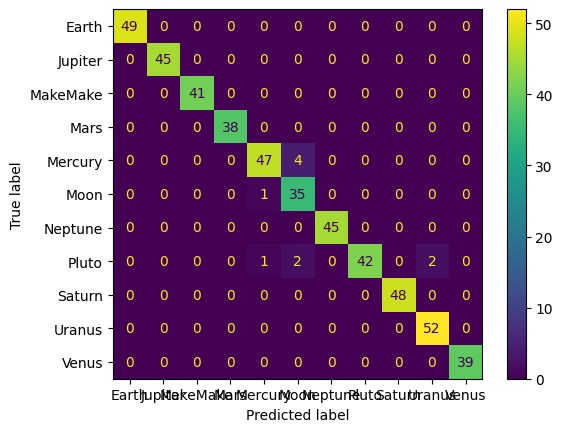

In [93]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
#Viendo el resultado vemos que para la mayoría de los casos el modelo clasifica muy bien, pero falla algunas veces: 4 veces en vez de Mercury dice Moon, 2 veces que dice Pluto en vez de Urano y alguno más

SVM

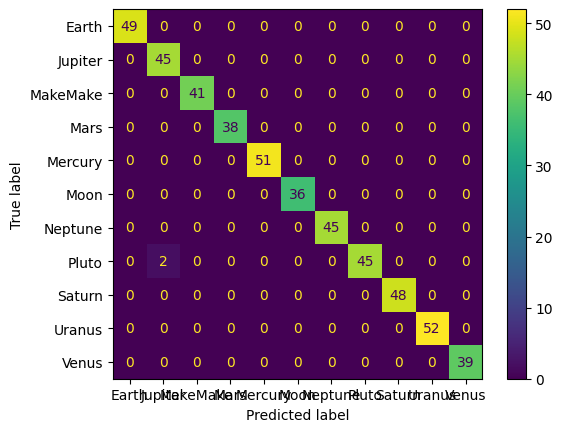

In [94]:
model = SVC(C=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
#Con el modelo SVM los resultados son aún mejores que para KNN teniendo solo 2 errores (Predice 2 veces Júpiter, cuando en realidad es Pluto)

Tree

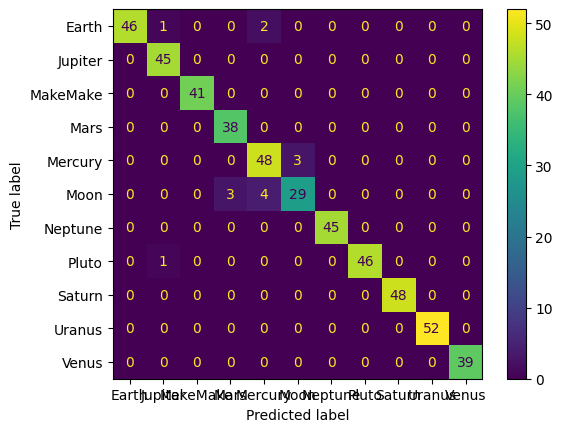

In [96]:
model = DecisionTreeClassifier(max_depth=8)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
#En este caso la mayoría de las veces acierta pero hay también muchos fallos, muchos más que SVM y algunos más que KNN. Entonces es el peor modelo

2. Scikit-Learn comes with a handy function named *classification_report*, that provides a range of evaluation metrics for classifiers. Search information about this function and provide a report of the SVM classifier.

In [99]:
from sklearn.metrics import classification_report
model = SVC(C=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))#Con esto se genera y se muestra un informe de evaluación del modelo
#La columna precision nos dice: (Ej: de todo lo que dice el modelo que es Júpiter, acierta un 96%)
#La columna recall nos dice que tanto detecta (Ej: Para Pluto detecta el 96%)
#La columna f1_score es un resumen (la media de los otras dos columnas)
#La columna support indica la cantidad de imágenes que hay de cada planeta
#La fila accuracy nos da el porcentaje total de aciertos
#La fila macro avg nos da la media de todas las clases (los trata a todos por igual aunque haya clases que tengan más datos)
#La fila weighted avg es la media ahora sí teniendo en cuenta los datos que hay por cada clase

              precision    recall  f1-score   support

       Earth       1.00      1.00      1.00        49
     Jupiter       0.96      1.00      0.98        45
    MakeMake       1.00      1.00      1.00        41
        Mars       1.00      1.00      1.00        38
     Mercury       1.00      1.00      1.00        51
        Moon       1.00      1.00      1.00        36
     Neptune       1.00      1.00      1.00        45
       Pluto       1.00      0.96      0.98        47
      Saturn       1.00      1.00      1.00        48
      Uranus       1.00      1.00      1.00        52
       Venus       1.00      1.00      1.00        39

    accuracy                           1.00       491
   macro avg       1.00      1.00      1.00       491
weighted avg       1.00      1.00      1.00       491



### Predictions on new data

We train models because we want to use them with data that does not belong to our dataset. We first train a production model evaluating its performance using the best scoring configuration we have seen so far, which is a 1-NN classifier (KNN with K=1).

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

model = KNeighborsClassifier(n_neighbors=1)

print(f"5-CV accuracy estimation: {cross_val_score(model, X, y, cv=5).mean()}")

5-CV accuracy estimation: 0.995103281364327


We've got a 99'7% accuracy! It seeems that our model is almost perfect, so we move on to put it into production, to this end we train it with the whole dataset for best performance.

In [38]:
model.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

That's nice, we finally have our model ready for fun. Now it is time to download an image.

In [39]:
from PIL import Image
import requests
from io import BytesIO

url = 'https://github.com/dfbarrero/dataCourse/raw/master/assignments/planets/earth.jpg'

response = requests.get(url)
img = Image.open(BytesIO(response.content))

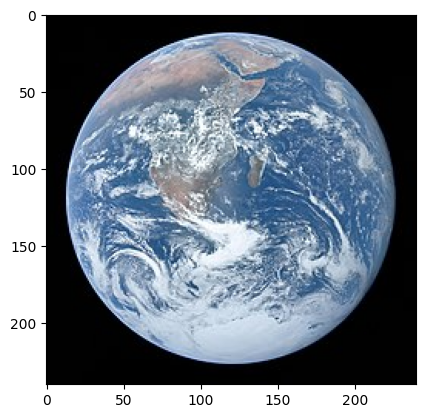

In [40]:
plt.imshow(img)

Good, now we have to preprocess the image to make our classifier happy.

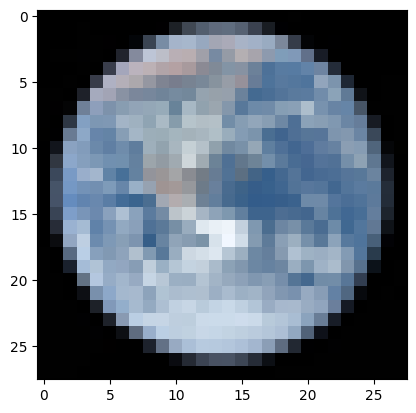

In [41]:
from PIL import ImageOps

border = (58, 2, 58, 2) # left, top, right, bottom
imgprocessed = ImageOps.crop(img, border)
imgprocessed = img.resize((28, 28))

plt.imshow(imgprocessed)

OK, the image has the format we wanted, but it is not still the NumPy array that out model expects. Let's do it.

In [42]:
imgdata = np.asarray(imgprocessed, dtype="uint8")
print(imgdata.shape)
imgdata = imgdata.reshape(1, -1)
print(imgdata.shape)

row = pd.DataFrame(imgdata, columns=['pixel'+str(i) for i in range(size)])
row_scaled = scaler.transform(row) # remember that we trained our models with standarized data

(28, 28, 3)
(1, 2352)


In [43]:
model.predict(row.values)

array(['Saturn'], dtype=object)

1. Observe that despite having a classifier with 99% accuracy, it classifies 'Earth' as 'Saturn'. So bad!. How do you explain this bad behaviour?

Con el modelo 1-NN se compara con solo el más cercano. Aunque tengamos una precisión del 99% no clasifica bien debido a un overfitting (sobreajuste). Tiene esa precisión porque se ajusta perfectamente a los datos de entrenamiento, tanto que en vez de generalizar se los aprende de memoria y por eso cuando probamos con una imagen nueva, como en este caso es la de la Tierra, lo clasifica mal.